<a href="https://colab.research.google.com/github/MiksterBerlin/Coupon_Usage_20250311/blob/This%26That/Coupon_usage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [23]:
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [24]:
data = pd.read_csv('sample_data/coupons.csv')

In [25]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [27]:
for col in data.columns:
    data1= data[col].value_counts()
    print(data1, "\n")

destination
No Urgent Place    6283
Home               3237
Work               3164
Name: count, dtype: int64 

passanger
Alone        7305
Friend(s)    3298
Partner      1075
Kid(s)       1006
Name: count, dtype: int64 

weather
Sunny    10069
Snowy     1405
Rainy     1210
Name: count, dtype: int64 

temperature
80    6528
55    3840
30    2316
Name: count, dtype: int64 

time
6PM     3230
7AM     3164
10AM    2275
2PM     2009
10PM    2006
Name: count, dtype: int64 

coupon
Coffee House             3996
Restaurant(<20)          2786
Carry out & Take away    2393
Bar                      2017
Restaurant(20-50)        1492
Name: count, dtype: int64 

expiration
1d    7091
2h    5593
Name: count, dtype: int64 

gender
Female    6511
Male      6173
Name: count, dtype: int64 

age
21         2653
26         2559
31         2039
50plus     1788
36         1319
41         1093
46          686
below21     547
Name: count, dtype: int64 

maritalStatus
Married partner      5100
Single         

3. Decide what to do about your missing data -- drop, replace, other...

In [28]:
for col in data.columns:
    na_value = data[col].isna().sum()
    if na_value > 0:
        data[col] = data[col].fillna(data[col].mode()[0])
        print(f"{col} has {na_value} missing values")

car has 12576 missing values
Bar has 107 missing values
CoffeeHouse has 217 missing values
CarryAway has 151 missing values
RestaurantLessThan20 has 130 missing values
Restaurant20To50 has 189 missing values


In [29]:
data=data.rename(columns={'Y': 'Coupon_used', 'passanger': 'passenger', 'age': 'age_groups'})
data ['age_group'] = data['age_group'] = data.loc[:, 'age_groups']
print(data.columns)

Index(['destination', 'passenger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age_groups', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Coupon_used', 'age_group'],
      dtype='object')


In [30]:
data2 = data.drop(['direction_opp', 'car'], axis=1)

In [88]:
data3=data2.replace({'Coupon_used': {0: 'No', 1: 'Yes'}, 'time':{'2PM': 14, '10AM': 10, '7AM': 7, '6PM': 18, '10PM': 22},
              'expiration': {'2h': 2, '1d': 24},
              'age_groups': {'below21': '<=25', '21': '<=25', '26': '>25', '31': '>25', '36': '>25', '41': '>25', '46':'>25', '51plus': ' >25'},
              'direction_same': {0:'No', 1:'Yes'},
               'toCoupon_GEQ5min': {1: '5'},
               'toCoupon_GEQ15min': {1: '15'},
              'toCoupon_GEQ25min': {1: '25'},
              'temperature': {30: '30F', 55: '55F', 80: '80F'},
              'weather': {1:'sunny', 2:'rainy', 3:'snowy'},
               })

print(data3)

           destination  passenger weather temperature  time  \
0      No Urgent Place      Alone   Sunny         55F    14   
1      No Urgent Place  Friend(s)   Sunny         80F    10   
2      No Urgent Place  Friend(s)   Sunny         80F    10   
3      No Urgent Place  Friend(s)   Sunny         80F    14   
4      No Urgent Place  Friend(s)   Sunny         80F    14   
...                ...        ...     ...         ...   ...   
12679             Home    Partner   Rainy         55F    18   
12680             Work      Alone   Rainy         55F     7   
12681             Work      Alone   Snowy         30F     7   
12682             Work      Alone   Snowy         30F     7   
12683             Work      Alone   Sunny         80F     7   

                      coupon  expiration  gender age_groups  \
0            Restaurant(<20)          24  Female       <=25   
1               Coffee House           2  Female       <=25   
2      Carry out & Take away           2  Female      

<ipython-input-88-2bcc3b939b2f>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data3=data2.replace({'Coupon_used': {0: 'No', 1: 'Yes'}, 'time':{'2PM': 14, '10AM': 10, '7AM': 7, '6PM': 18, '10PM': 22},


4. What proportion of the total observations chose to accept the coupon?



Coupon_used
Yes    7210
No     5474
Name: count, dtype: int64


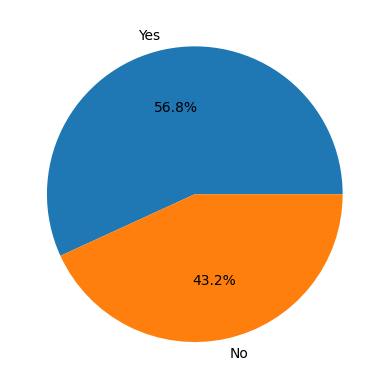

In [89]:
Yes= data3['Coupon_used'].value_counts()
print(Yes)
plt.pie(Yes, labels = Yes.index, autopct='%1.1f%%')
plt.show()

5. Use a bar plot to visualize the `coupon` column.

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Restaurant(<20)'),
  Text(1, 0, 'Coffee House'),
  Text(2, 0, 'Carry out & Take away'),
  Text(3, 0, 'Bar'),
  Text(4, 0, 'Restaurant(20-50)')])

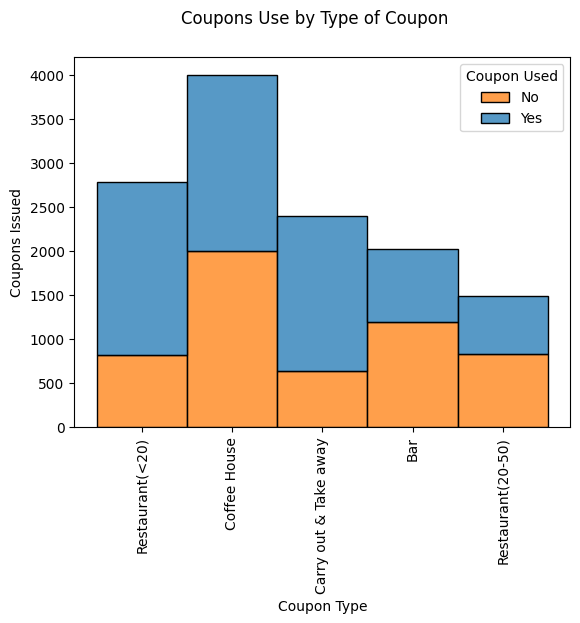

In [90]:
sns.histplot(data3, x = "coupon", hue = "Coupon_used", multiple = "stack")
plt.xlabel("Coupon Type")
plt.ylabel("Coupons Issued")
plt.suptitle("Coupons Use by Type of Coupon")
plt.legend(title="Coupon Used", loc="upper right", labels=["No", "Yes"])
plt.xticks(rotation = 90)

6. Use a histogram to visualize the temperature column.

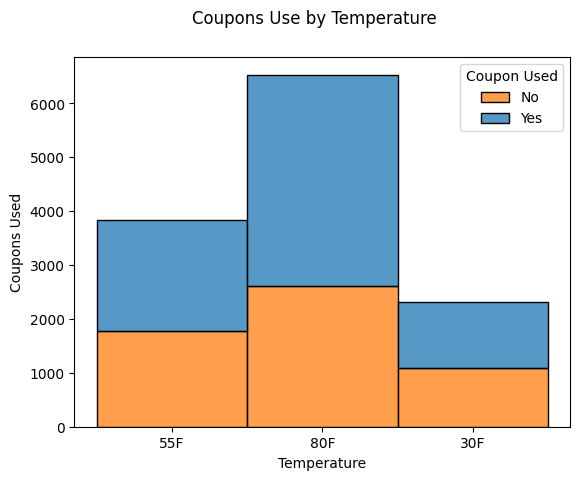

In [91]:
sns.histplot(data3, x = "temperature", hue='Coupon_used' , multiple = "stack")
plt.xlabel("Temperature")
plt.ylabel("Coupons Used")
plt.suptitle("Coupons Use by Temperature")
plt.legend(title="Coupon Used", loc="upper right", labels=["No", "Yes"])

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [92]:
Bar = data3[data3['coupon'] == 'Bar']
Bar2 = Bar.replace({'Bar': {'1~3': '<=3', 'never': '<=3', '4~8': '>3', 'gt8': '>3', 'less1': '<=3'}})
print(Bar2)

           destination  passenger weather temperature  time coupon  \
9      No Urgent Place     Kid(s)   Sunny         80F    10    Bar   
13                Home      Alone   Sunny         55F    18    Bar   
17                Work      Alone   Sunny         55F     7    Bar   
24     No Urgent Place  Friend(s)   Sunny         80F    10    Bar   
35                Home      Alone   Sunny         55F    18    Bar   
...                ...        ...     ...         ...   ...    ...   
12663  No Urgent Place  Friend(s)   Sunny         80F    22    Bar   
12664  No Urgent Place  Friend(s)   Sunny         55F    22    Bar   
12667  No Urgent Place      Alone   Rainy         55F    10    Bar   
12670  No Urgent Place    Partner   Rainy         55F    18    Bar   
12682             Work      Alone   Snowy         30F     7    Bar   

       expiration  gender age_groups      maritalStatus  ...  CoffeeHouse  \
9              24  Female       <=25  Unmarried partner  ...        never   
13   

2. What proportion of bar coupons were accepted?


Coupon_used
No     1190
Yes     827
Name: count, dtype: int64


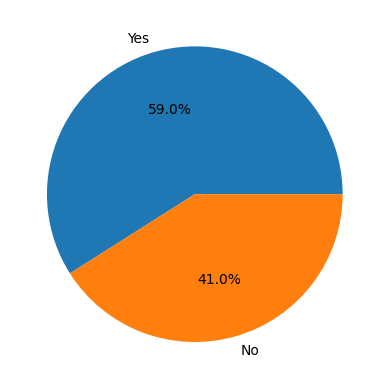

In [93]:
Yes_Bar= Bar['Coupon_used'].value_counts()
print(Yes_Bar)
plt.pie(Yes_Bar, labels = Yes.index, autopct='%1.1f%%')
plt.show()

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


([0, 1], [Text(0, 0, '<=3'), Text(1, 0, '>3')])

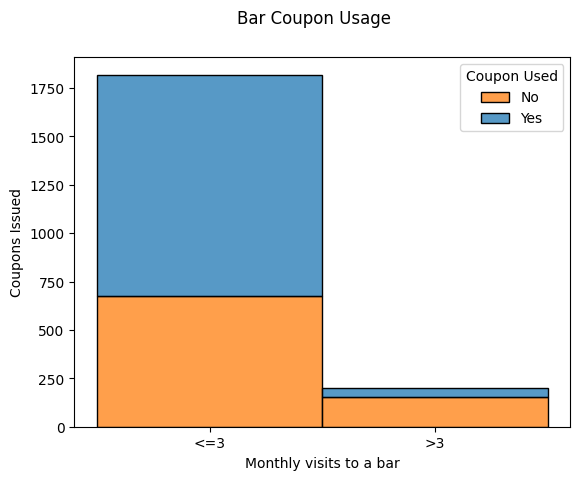

In [94]:
sns.histplot(Bar2, x = "Bar", hue = "Coupon_used", multiple = "stack")
plt.xlabel("Monthly visits to a bar")
plt.ylabel("Coupons Issued")
plt.suptitle("Bar Coupon Usage")
plt.legend(title="Coupon Used", loc="upper right", labels=["No", "Yes"])
plt.xticks(rotation = 0)

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


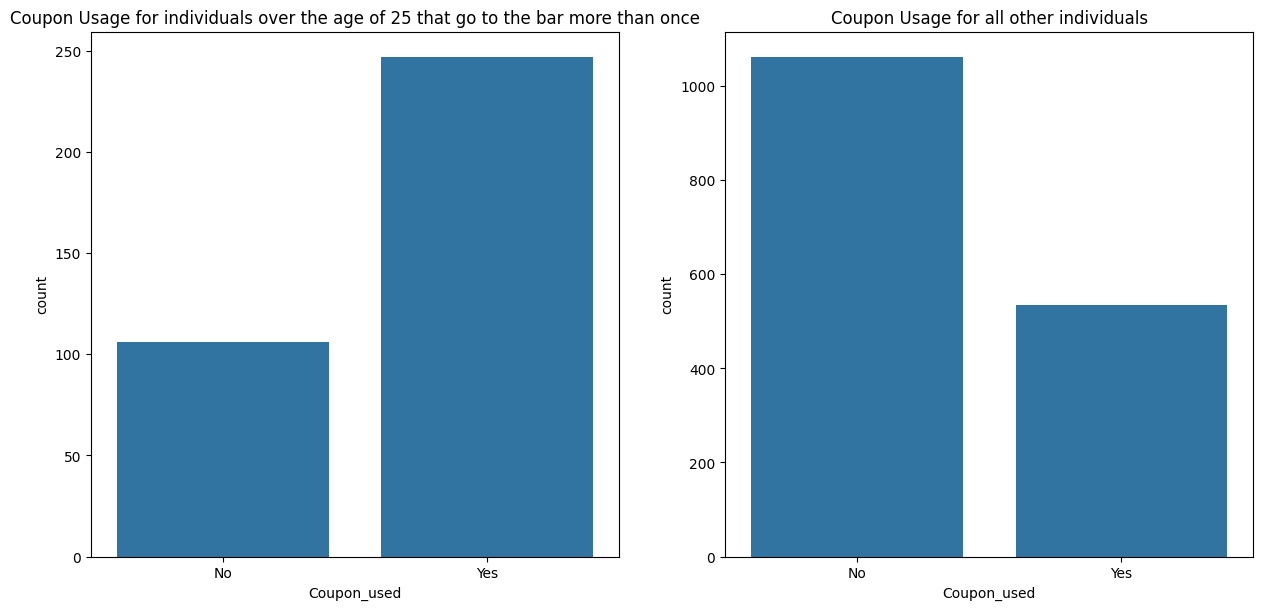

In [95]:
Bar3 = Bar.replace({'Bar': {'1~3': 'More than once', 'never': 'Other', '4~8': 'More than once', 'gt8': 'More than once', 'less1': 'Other'} })
Bar4 = Bar3.query('(Bar== "More than once") and (age_groups == ">25")')['Coupon_used'].value_counts().to_frame().sort_values(by = 'Coupon_used').reset_index()
Bar5 = Bar3.query('(Bar== "Other") or (age_groups == "<=25")')['Coupon_used'].value_counts().to_frame().sort_values(by = 'Coupon_used').reset_index()

plt.figure(figsize=(15,15))

# Plot pi charts
plt.subplot(2,2,1)
sns.barplot(data=Bar4, x = "Coupon_used", y = 'count')
plt.title("Coupon Usage for individuals over the age of 25 that go to the bar more than once")
plt.xticks([0,1], ["No", "Yes"])

plt.subplot(2,2,2)
sns.barplot(data=Bar5, x = "Coupon_used", y = 'count')
plt.title("Coupon Usage for all other individuals")
plt.xticks([0,1], ["No", "Yes"])

plt.show()

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


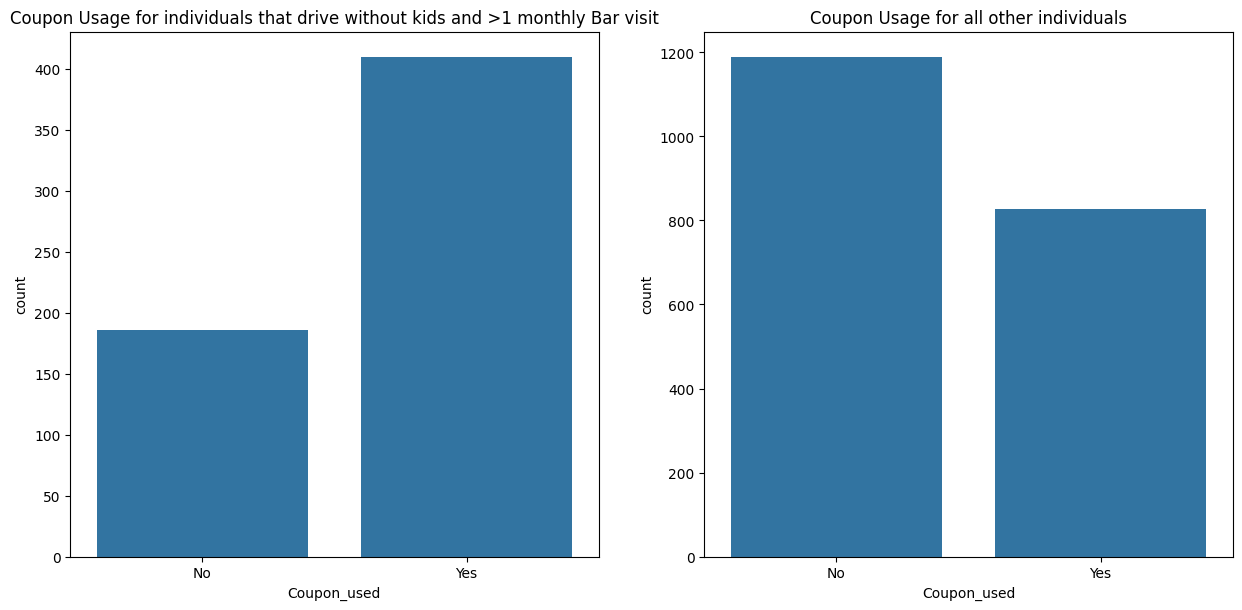

In [96]:
Bar6 = Bar3.query('(Bar== "More than once") and (passenger != "Kids") and (occupation != "farming") and (occupation != "forestry") and (occupation != "fishing")')['Coupon_used'].value_counts().to_frame().sort_values(by = 'Coupon_used').reset_index()
Bar7 = Bar3.query('(Bar== "Other") or (passenger!= "Kids") or (occupation != "farming") or (occupation != "forestry") or (occupation != "fishing")')['Coupon_used'].value_counts().to_frame().sort_values(by = 'Coupon_used').reset_index()

plt.figure(figsize=(15,15))

# Plot pi charts
plt.subplot(2,2,1)
sns.barplot(data=Bar6, x = "Coupon_used", y = 'count')
plt.title("Coupon Usage for individuals that drive without kids and >1 monthly Bar visit")
plt.xticks([0,1], ["No", "Yes"])

plt.subplot(2,2,2)
sns.barplot(data=Bar7, x = "Coupon_used", y = 'count')
plt.title("Coupon Usage for all other individuals")
plt.xticks([0,1], ["No", "Yes"])

plt.show()

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



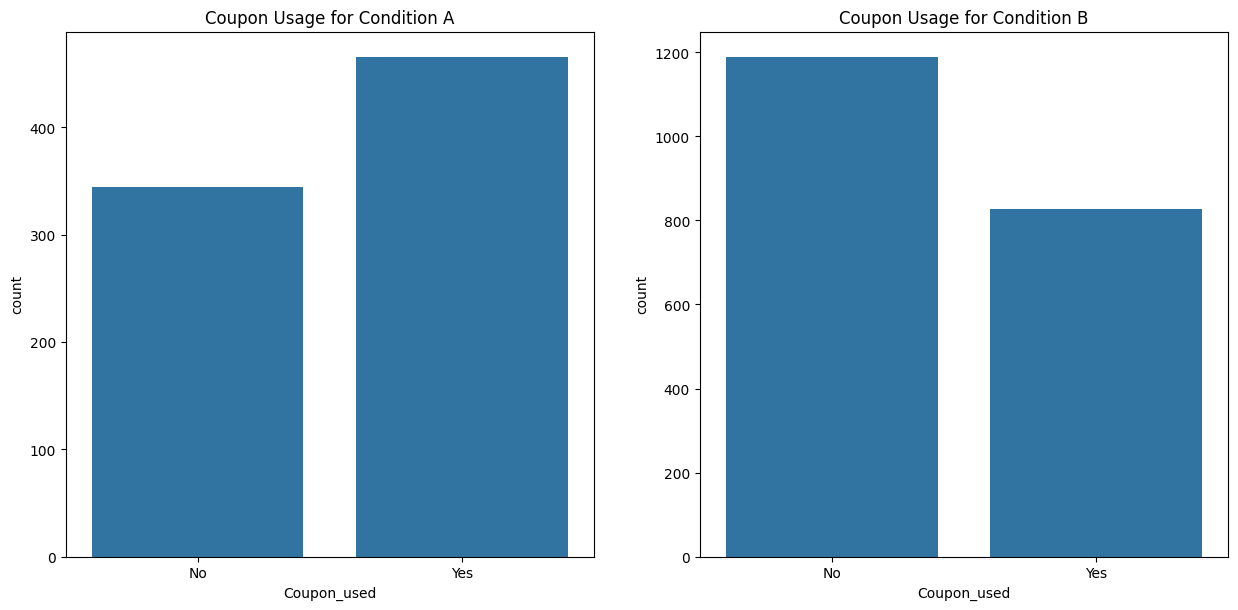

In [97]:
Under30 = ['below21', '21', '26']  # over 30 year olds
Less_50K = ['Less than $12500','$12500 - $24999','$25000 - $37499','$37500 - $49999'] #income levels below $50,000

Bar7 = Bar3.query('(Bar == "More than once") and (passenger != "Kids") and (maritalStatus != "Widowed") or \
                  (Bar == "More than once") and (age_groups in @Under30) or \
                  (RestaurantLessThan20 == "4~8" or RestaurantLessThan20 == "gt8") and (income in @Less_50K)')['Coupon_used'].value_counts().to_frame().sort_values(by='Coupon_used').reset_index()
Bar8 = Bar3.query('(Bar== "More than once") or (passenger != "Kids") or (age_group in @Under30) or (income in @Less_50K)')['Coupon_used'].value_counts().to_frame().sort_values(by = 'Coupon_used').reset_index()

plt.figure(figsize=(15,15))

# Plot pi charts
plt.subplot(2,2,1)
sns.barplot(data=Bar7, x = "Coupon_used", y = 'count')
plt.title("Coupon Usage for Condition A")
plt.xticks([0,1], ["No", "Yes"])

plt.subplot(2,2,2)
sns.barplot(data=Bar8, x = "Coupon_used", y = 'count')
plt.title("Coupon Usage for Condition B")
plt.xticks([0,1], ["No", "Yes"])

plt.show()

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [ ]:
#Individuals over the age of 25, that earn more than $50,000, drive without a kid and frequent the bar more than once but <=3 times a month are the most likely to accept the coupon.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [98]:
# Coupon Usage for Coffee Houses
Coffee = data3[data3['coupon'] == 'Coffee House']
Coffee = Coffee.replace({'CoffeeHouse': {'never': '0', '4~8': '>4', 'gt8': '>4', 'less1': '<1'}})
print(Coffee)

           destination  passenger weather temperature  time        coupon  \
1      No Urgent Place  Friend(s)   Sunny         80F    10  Coffee House   
3      No Urgent Place  Friend(s)   Sunny         80F    14  Coffee House   
4      No Urgent Place  Friend(s)   Sunny         80F    14  Coffee House   
12     No Urgent Place     Kid(s)   Sunny         55F    18  Coffee House   
15                Home      Alone   Sunny         80F    18  Coffee House   
...                ...        ...     ...         ...   ...           ...   
12656             Home      Alone   Snowy         30F    22  Coffee House   
12659             Work      Alone   Snowy         30F     7  Coffee House   
12674             Home      Alone   Rainy         55F    22  Coffee House   
12675             Home      Alone   Snowy         30F    22  Coffee House   
12681             Work      Alone   Snowy         30F     7  Coffee House   

       expiration  gender age_groups      maritalStatus  ...  CoffeeHouse  

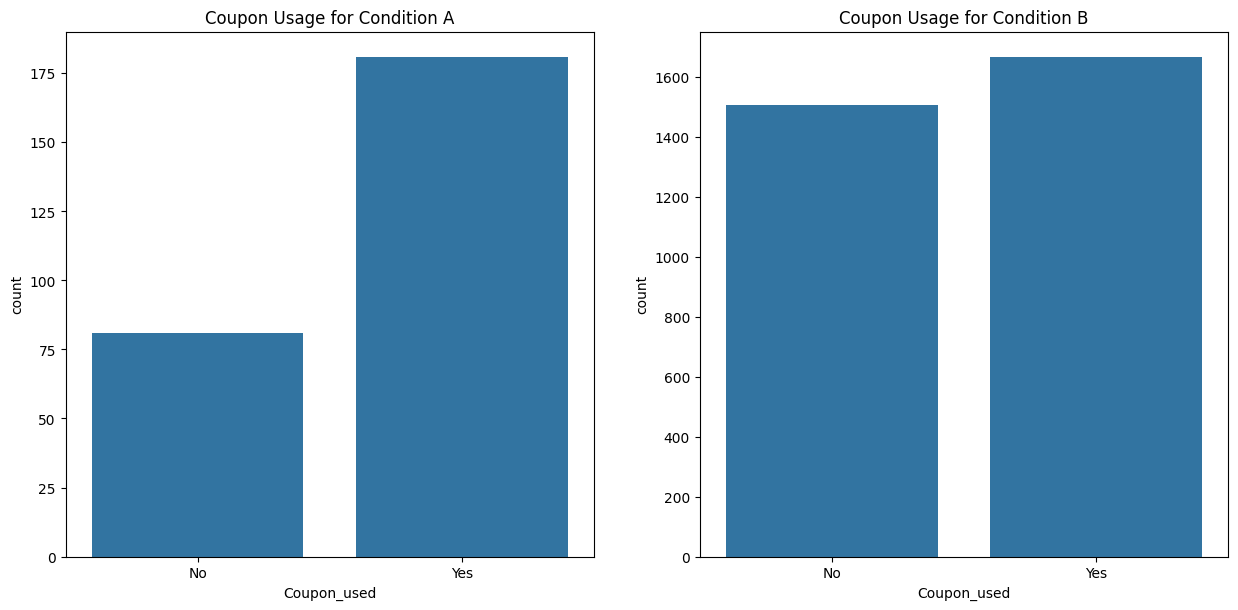

In [99]:
Under30 = ['below21', '21', '26']  #subset to individuals under the age of 30
Less_50K = ['Less than $12500','$12500 - $24999','$25000 - $37499','$37500 - $49999'] #subset to an income level below $50,000

Coffee2 = Coffee.query('(CoffeeHouse == ">4") and (income in @Less_50K) and (age_group in @Under30)')['Coupon_used'].value_counts().to_frame().sort_values(by='Coupon_used').reset_index()
Coffee3 = Coffee.query('(CoffeeHouse== ">4") or (age_group in @Under30) or (income in @Less_50K)')['Coupon_used'].value_counts().to_frame().sort_values(by = 'Coupon_used').reset_index()

plt.figure(figsize=(15,15))

# Plot pi charts
plt.subplot(2,2,1)
sns.barplot(data=Coffee2, x = "Coupon_used", y = 'count')
plt.title("Coupon Usage for Condition A")
plt.xticks([0,1], ["No", "Yes"])

plt.subplot(2,2,2)
sns.barplot(data=Coffee3, x = "Coupon_used", y = 'count')
plt.title("Coupon Usage for Condition B")
plt.xticks([0,1], ["No", "Yes"])

plt.show()

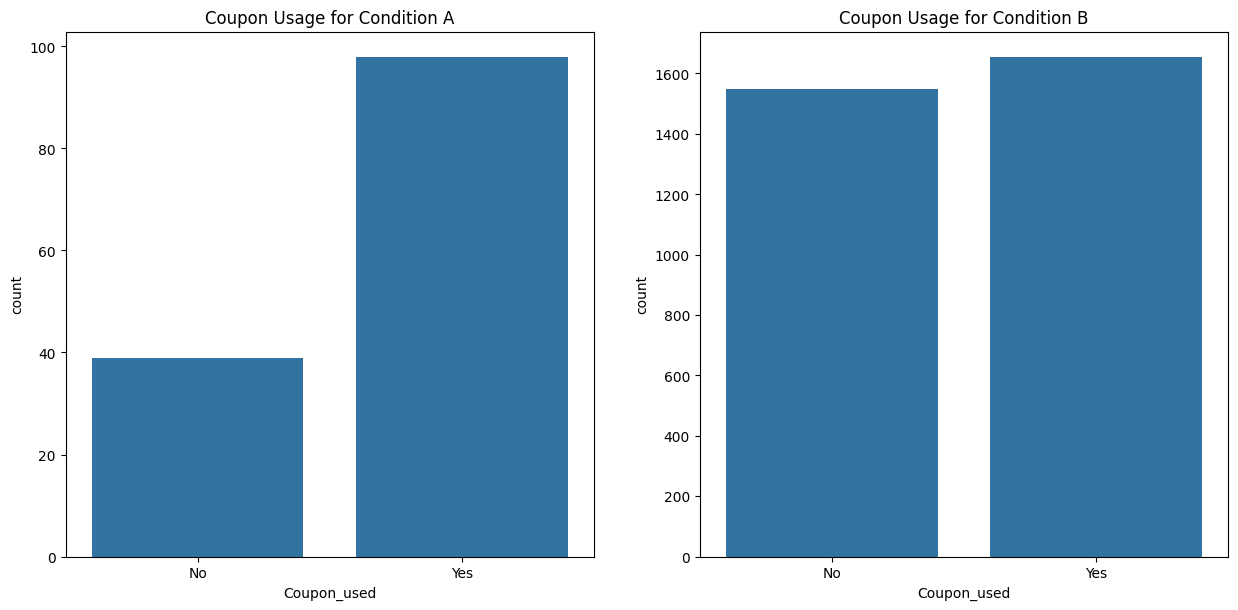

In [100]:
Over30 = ['51plus', '31', '36', '41', '46']  #subset to individuals over the age of 30
Less_50K = ['Less than $12500','$12500 - $24999','$25000 - $37499','$37500 - $49999']

Coffee4 = Coffee.query('(CoffeeHouse == ">4") and (income in @Less_50K) and (age_group in @Over30)')['Coupon_used'].value_counts().to_frame().sort_values(by='Coupon_used').reset_index()
Coffee5 = Coffee.query('(CoffeeHouse== ">4") or (age_group in @Over30) or (income in @Less_50K)')['Coupon_used'].value_counts().to_frame().sort_values(by = 'Coupon_used').reset_index()

plt.figure(figsize=(15,15))

# Plot pi charts
plt.subplot(2,2,1)
sns.barplot(data=Coffee4, x = "Coupon_used", y = 'count')
plt.title("Coupon Usage for Condition A")
plt.xticks([0,1], ["No", "Yes"])

plt.subplot(2,2,2)
sns.barplot(data=Coffee5, x = "Coupon_used", y = 'count')
plt.title("Coupon Usage for Condition B")
plt.xticks([0,1], ["No", "Yes"])

plt.show()

([<matplotlib.axis.XTick at 0x7e378dbd1f90>,
 [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

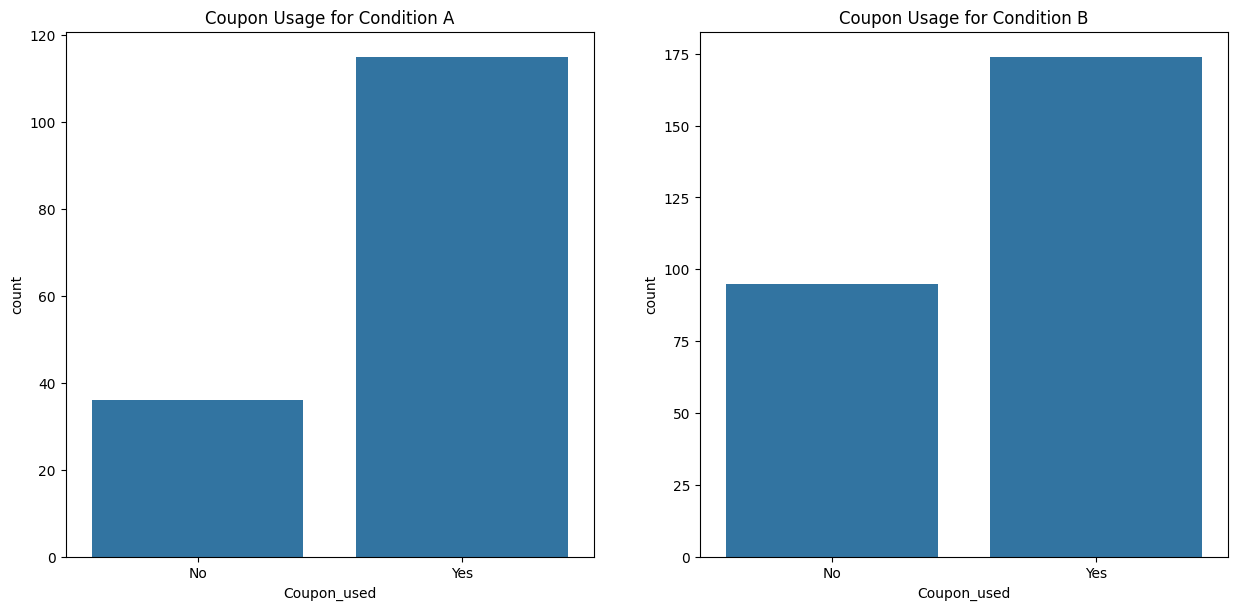

In [101]:

Under30 = ['below21', '21', '26']

Coffee6 = Coffee.query('(CoffeeHouse == ">4") and (gender == "Female") and (age_group in @Under30)')['Coupon_used'].value_counts().to_frame().sort_values(by='Coupon_used').reset_index()
Coffee7 = Coffee.query('(CoffeeHouse== ">4") and (gender == "Male") and (age_group in @Under30)')['Coupon_used'].value_counts().to_frame().sort_values(by = 'Coupon_used').reset_index()

plt.figure(figsize=(15,15))

# Plot pi charts
plt.subplot(2,2,1)
sns.barplot(data=Coffee6, x = "Coupon_used", y = 'count')
plt.title("Coupon Usage for Condition A")
plt.xticks([0,1], ["No", "Yes"])

plt.subplot(2,2,2)
sns.barplot(data=Coffee7, x = "Coupon_used", y = 'count')
plt.title("Coupon Usage for Condition B")
plt.xticks([0,1], ["No", "Yes"])

([<matplotlib.axis.XTick at 0x7e378d74ea10>,
 [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

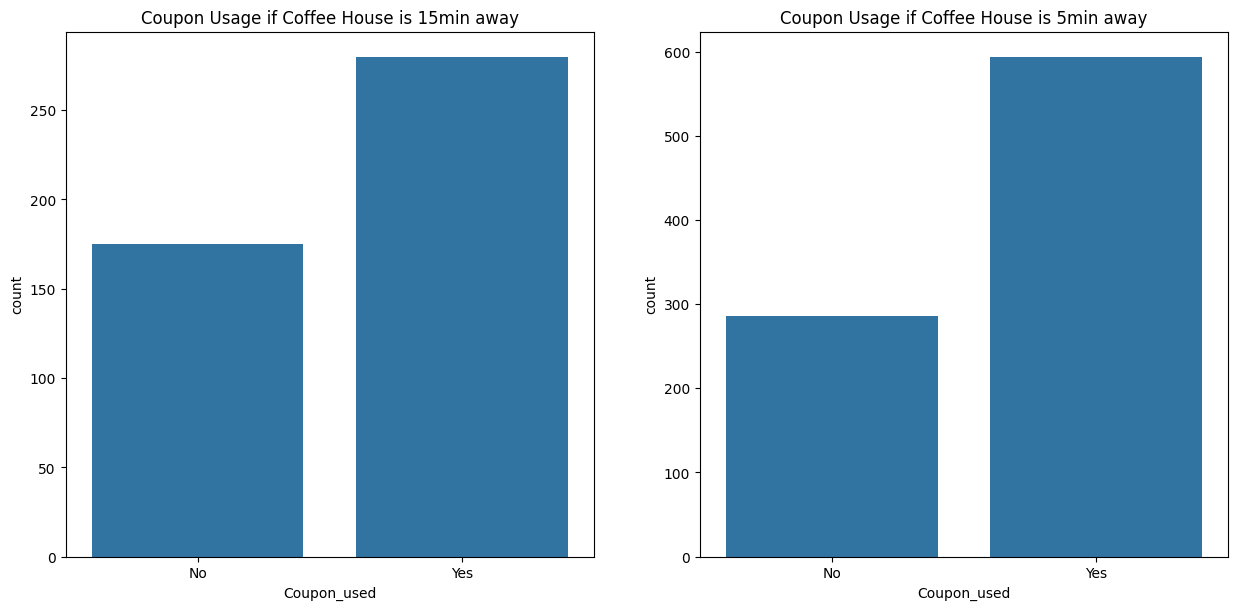

In [117]:

Coffee10 = Coffee.query('(CoffeeHouse == ">4") and (toCoupon_GEQ15min == "15")')['Coupon_used'].value_counts().to_frame().sort_values(by='Coupon_used').reset_index()
Coffee11 = Coffee.query('(CoffeeHouse == ">4") and (toCoupon_GEQ5min == "5")')['Coupon_used'].value_counts().to_frame().sort_values(by = 'Coupon_used').reset_index()

plt.figure(figsize=(15,15))

# Plot pi charts
plt.subplot(2,2,1)
sns.barplot(data=Coffee10, x = "Coupon_used", y = 'count')
plt.title("Coupon Usage if Coffee House is 15min away")
plt.xticks([0,1], ["No", "Yes"])

plt.subplot(2,2,2)
sns.barplot(data=Coffee11, x = "Coupon_used", y = 'count')
plt.title("Coupon Usage if Coffee House is 5min away")
plt.xticks([0,1], ["No", "Yes"])